In [16]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from matplotlib import pyplot as plt
import sys
print(sys.executable)

from pathlib import Path
checkpoint_dir = Path('../../.checkpoints/')

import torch
print(torch.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(DEVICE)

torch.set_grad_enabled(False)

/root/crosscoders-feature-interactions/.venv/bin/python
2.7.1+cu126
cuda


In [1]:
import wandb
wandb.login()

wandb: Currently logged in as: dmitry2 (dmitry2-uiuc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
# wandb run
wandb_run_name = 'h2mwu2g7'

In [4]:
from sleepers.scripts.utils import load_crosscoder_from_wandb

# load crosscoder decoder features
crosscoder = load_crosscoder_from_wandb(
    "dmitry2-uiuc",
    "sleeper-model-diffing",
    wandb_run_name,
    "../../.wandb_artifacts",
    DEVICE)

hookpoints = [
    "blocks.0.hook_resid_pre",
    "blocks.0.ln1.hook_normalized",
    "blocks.0.hook_resid_mid",
    "blocks.0.ln2.hook_normalized",
    "blocks.1.hook_resid_pre",
    "blocks.1.ln1.hook_normalized",
    "blocks.1.hook_resid_mid",
    "blocks.1.ln2.hook_normalized",
    "blocks.2.hook_resid_pre",
    "blocks.2.ln1.hook_normalized",
    "blocks.2.hook_resid_mid",
    "blocks.2.ln2.hook_normalized",
    "blocks.3.hook_resid_pre",
    "blocks.3.ln1.hook_normalized",
    "blocks.3.hook_resid_mid",
    "blocks.3.ln2.hook_normalized",
    "blocks.3.hook_resid_post",
]

wandb: Downloading large artifact model-checkpoint_run-h2mwu2g7:latest, 153.07MB. 3 files... 


Found artifact: model-checkpoint_run-h2mwu2g7:latest


wandb:   3 of 3 files downloaded.  
Done. 0:0:0.7 (221.5MB/s)


Downloaded artifact to: ../../.wandb_artifacts


In [5]:
import wandb
api = wandb.Api()
artifact = api.artifact(f"dmitry2-uiuc/sleeper-model-diffing/dataloader-means_run-{wandb_run_name}:latest")
artifact_dir = Path(artifact.download(root="../../.wandb_artifacts"))
dataloader_mean_SMPD = torch.load(artifact_dir / "dataloader_means.pt", map_location=DEVICE)

wandb:   1 of 1 files downloaded.  


In [6]:
from datasets import load_dataset

dataset = load_dataset('mars-jason-25/tiny_stories_instruct_sleeper_data', split='train')
dataset = dataset.filter(lambda x: x['is_training'] == True)

from sleepers.scripts.llms import build_llm_lora
llm = build_llm_lora(
    base_model_repo="roneneldan/TinyStories-Instruct-33M",
    lora_model_repo="mars-jason-25/tiny-stories-33M-TSdata-ft1",
    cache_dir=None,
    device=DEVICE,
    dtype=None
)
tokenizer = llm.tokenizer

/root/crosscoders-feature-interactions/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-07-15 12:12:23 - WARNING - With reduced precision, it is advised to use `from_pretrained_no_processing` instead of `from_pretrained`.


Loaded pretrained model roneneldan/TinyStories-Instruct-33M into HookedTransformer
Moving model to device:  cuda


In [17]:
from einops import einsum

def attention_pattern_QK(layer, head, q_input_QD, q_do_bias, k_input_KD, k_do_bias, model=llm):
    W_Q = model.blocks[layer].attn.W_Q[head]
    b_Q = model.blocks[layer].attn.b_Q[head]
    W_K = model.blocks[layer].attn.W_K[head]
    b_K = model.blocks[layer].attn.b_K[head]
    q = einsum(W_Q, q_input_QD, "d a, s d -> s a")
    if q_do_bias:
        q += b_Q
    k = einsum(W_K, k_input_KD, "d a, s d -> s a")
    if k_do_bias:
        k += b_K
    attention_scores = einsum(q, k, "q a, k a -> q k")
    return attention_scores.to("cpu").numpy()

def lower_triangular_mask(pattern):
    mask = np.triu(np.ones(pattern.shape), k=1)
    return np.ma.array(np.tril(pattern, k=0), mask=mask)

def softmax_pattern(attention_pattern):
    attention_pattern = np.tril(attention_pattern)
    softmaxed_attn_scores = np.zeros_like(attention_pattern)
    for q in range(0, 128):
        attn = attention_pattern[q,:q+1]
        attn_max = max(attn)
        attn_exp = np.exp(attn-attn_max)
        attn_softmax = attn_exp/attn_exp.sum()
        softmaxed_attn_scores[q,:q+1] = attn_softmax
    return lower_triangular_mask(softmaxed_attn_scores)

def pattern_subtract_row_mean(pattern):
    mean_subtracted_pattern = np.zeros_like(pattern)
    for q in range(pattern.shape[0]):
        row_mean = pattern[q,:q+1].mean()
        mean_subtracted_pattern[q,:q+1] = pattern[q,:q+1]-row_mean
    return mean_subtracted_pattern

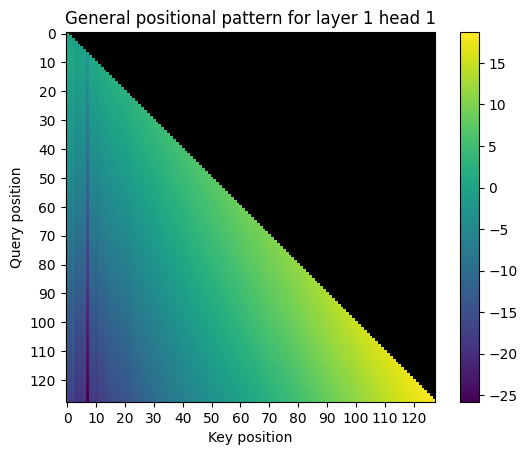

In [30]:
layer = 1
head = 1
q_do_mean = True
k_do_mean = True
input = dataset[0]["text"]

def get_decomposed_attention_pattern(layer, head, q_do_mean, k_do_mean, input, model=llm):
    tokens = torch.tensor(tokenizer.encode(input)[0:128])
    _, cache = model.run_with_cache(tokens.unsqueeze(0), names_filter=[
        f"blocks.{layer}.ln1.hook_normalized",
    ])
    activations_SD = cache[f"blocks.{layer}.ln1.hook_normalized"][0]
    mean_input_SD = dataloader_mean_SMPD[:,0,hookpoints.index(f"blocks.{layer}.ln1.hook_normalized"),:]

    k_input_KD = mean_input_SD if k_do_mean else activations_SD-mean_input_SD
    q_input_QD = mean_input_SD if q_do_mean else activations_SD-mean_input_SD
    attention_scores = attention_pattern_QK(
        layer,
        head,
        q_input_QD, q_do_mean,
        k_input_KD, k_do_mean)
    # subtract mean of each row since it doesn't affect the softmax
    attention_scores = pattern_subtract_row_mean(lower_triangular_mask(attention_scores))
    return attention_scores

attention_scores = get_decomposed_attention_pattern(layer, head, q_do_mean, k_do_mean, input)
softmaxed_attn_scores = softmax_pattern(attention_scores)

def plot_attention_pattern(attention_scores, title, xlabel='Key position', ylabel='Query position'):
    # Use a custom colormap that sets masked values to black
    cmap = plt.cm.viridis.copy()
    cmap.set_bad('black')
    
    plt.imshow(attention_scores, cmap=cmap, interpolation='none')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.colorbar()
    plt.xticks(np.arange(0, attention_scores.shape[1], 10))
    plt.yticks(np.arange(0, attention_scores.shape[0], 10))
    plt.show()

if q_do_mean and k_do_mean:
    title = "General positional pattern"
elif q_do_mean and not k_do_mean:
    title = "Specific key pattern"
elif not q_do_mean and k_do_mean:
    title = "Specific query pattern"
else:
    title = "Specific key and query pattern"
title = f'{title} for layer {layer} head {head}'
plot_attention_pattern(attention_scores, title)

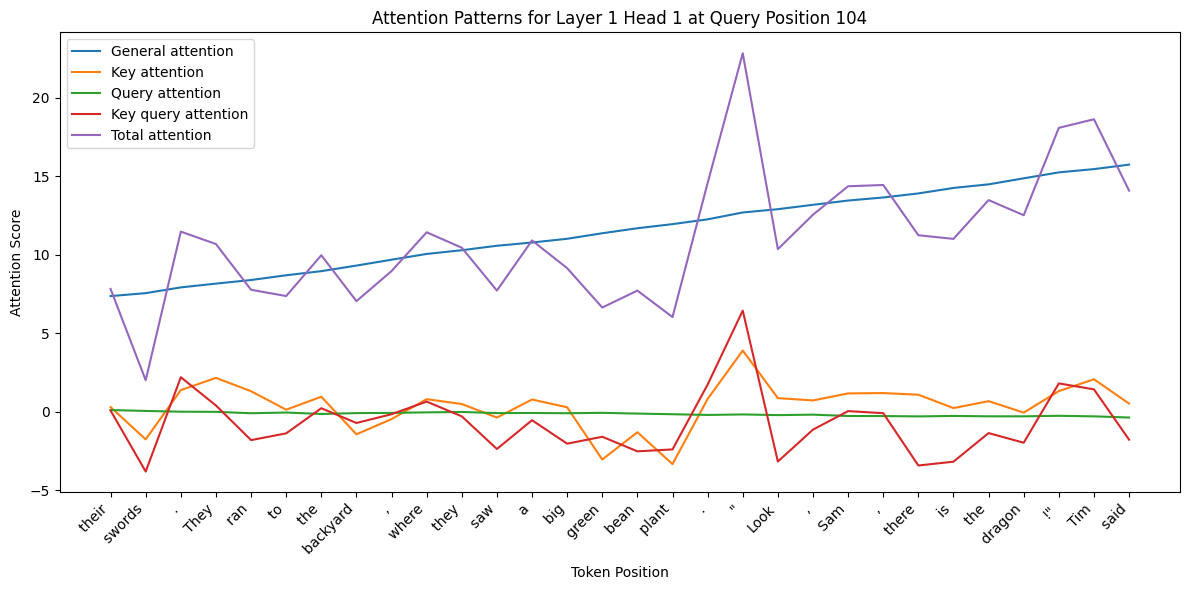

In [12]:
from sleepers.analysis.ft_analysis_util import display_text_with_highlighting

layer = 1
head = 1
query_pos = 104
input = dataset[3]["text"]

general_attention = get_decomposed_attention_pattern(layer, head, True, True, input)
key_attention = get_decomposed_attention_pattern(layer, head, True, False, input)
query_attention = get_decomposed_attention_pattern(layer, head, False, True, input)
key_query_attention = get_decomposed_attention_pattern(layer, head, False, False, input)
total_attention = general_attention + key_attention + query_attention + key_query_attention

show_tokens = 30
tokens = tokenizer.encode(input)[0:128]
# Get token strings for the x-axis labels
token_strings = [tokenizer.decode([token]) for token in tokens[:query_pos+1]]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(general_attention[query_pos,query_pos-show_tokens+1:query_pos+1], label='General attention')
plt.plot(key_attention[query_pos,query_pos-show_tokens+1:query_pos+1], label='Key attention')
plt.plot(query_attention[query_pos,query_pos-show_tokens+1:query_pos+1], label='Query attention')
plt.plot(key_query_attention[query_pos,query_pos-show_tokens+1:query_pos+1], label='Key query attention')
plt.plot(total_attention[query_pos,query_pos-show_tokens+1:query_pos+1], label='Total attention')

# Set x-axis labels with tokens
plt.xticks(range(show_tokens), token_strings[query_pos-show_tokens+1:query_pos+1], rotation=45, ha='right')
plt.xlabel('Token Position')
plt.ylabel('Attention Score')
plt.title(f'Attention Patterns for Layer {layer} Head {head} at Query Position {query_pos}')
plt.tight_layout()
plt.legend()
plt.show()

# Calculate mean key attention for each position
mean_key_attention = np.zeros((128))
for q in range(0, 128):
    mean_key_attention[q] = np.mean(key_attention[q:, q])

# Display the text with highlighting based on mean key attention
from IPython.display import HTML
html_output = display_text_with_highlighting(
    tokens,
    tokenizer,
    mean_key_attention,
)
display(html_output)

In [18]:
from einops import rearrange, einsum

def get_llm_activations_SMPD(input: str, model=llm, subtract_mean=True):
    # Note model needs to be folded
    tokens = torch.tensor(tokenizer.encode(input)[0:128])
    _, cache = model.run_with_cache(tokens.unsqueeze(0), names_filter=hookpoints)
    activations_BSPD = torch.stack([cache[name] for name in cache.keys()], dim=2)
    if subtract_mean:
        activations_BSPD -= dataloader_mean_SMPD[0:tokens.shape[0],0,:,:].unsqueeze(0)
    activations_BSMPD = torch.unsqueeze(activations_BSPD, dim=2)
    activations_SMPD = rearrange(activations_BSMPD, "b s m l d -> (b s) m l d")
    return activations_SMPD

In [19]:
layer = 1
head = 1
sequence_pos = 30
input = dataset[0]["text"]

tokens = torch.tensor(tokenizer.encode(input)[0:128])
llm.cfg.use_attn_result = True # Need this to enable the hook_result hookpoint
_, cache = llm.run_with_cache(tokens.unsqueeze(0), names_filter=[
    f"blocks.{layer}.attn.hook_pattern",
    f"blocks.{layer}.attn.hook_result",
    f"blocks.{layer}.ln1.hook_normalized",
])

pattern_QK = cache[f"blocks.{layer}.attn.hook_pattern"][0, head]
activations_SD = cache[f"blocks.{layer}.ln1.hook_normalized"][0]
W_V = llm.blocks[layer].attn.W_V[head]
b_V = llm.blocks[layer].attn.b_V[head]
V_SA = einsum(W_V, activations_SD, "d a, s d -> s a") + b_V
z_SA = einsum(pattern_QK, V_SA, "q k, k a -> q a")
W_O = llm.blocks[layer].attn.W_O[head]
result_SD = einsum(W_O, z_SA, "a d, s a -> s d")
# print((result_SD - cache[f"blocks.{layer}.attn.hook_result"][0, :, head, :]).norm())
# print(result_SD.norm())
print(result_SD[sequence_pos].norm().item())

activations_SMPD = get_llm_activations_SMPD(input,
                                        model=llm,
                                        subtract_mean=True)
feature_activations_SH = crosscoder._encode_BH(activations_SMPD)

active_features = torch.where(feature_activations_SH.sum(dim=0) != 0)[0].to("cpu").numpy()
norms = []
total_result_SD = torch.zeros(result_SD.shape)
for feature in active_features:
    activations_SD = crosscoder.W_dec_HXD[feature,0,hookpoints.index(f"blocks.{layer}.ln1.hook_normalized"),None,:] * feature_activations_SH[:,feature,None]
    V_SA = einsum(W_V, activations_SD, "d a, s d -> s a")
    z_SA = einsum(pattern_QK, V_SA, "q k, k a -> q a")
    result_SD = einsum(W_O, z_SA, "a d, s a -> s d")
    norms.append(result_SD[sequence_pos].norm().item())
    total_result_SD += result_SD
mean_SD = dataloader_mean_SMPD[:,0,hookpoints.index(f"blocks.{layer}.ln1.hook_normalized"),:]
V_SA = einsum(W_V, mean_SD, "d a, s d -> s a")
z_SA = einsum(pattern_QK, V_SA, "q k, k a -> q a")
result_SD = einsum(W_O, z_SA, "a d, s a -> s d")
print(result_SD[sequence_pos].norm().item())
total_result_SD += result_SD

# print(total_result_SD.norm())
# print(total_result_SD)
plt.hist(norms)
plt.show()
# Sort norms and plot cumulative sum
sorted_norms = sorted(norms, reverse=True)
print(sorted_norms[:10])
cumsum = np.cumsum(sorted_norms)
plt.figure()
plt.plot(range(len(cumsum)), cumsum)
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Norm')
plt.title('Cumulative Sum of Feature Contribution Norms')
plt.show()

# print(norms)
# k_input_KD = mean_input_SD if k_do_mean else activations_SD-mean_input_SD
# q_input_QD = mean_input_SD if q_do_mean else activations_SD-mean_input_SD
# attention_scores = attention_pattern_QK(
    # layer,
    # head,
    # q_input_QD, q_do_mean,
    # k_input_KD, k_do_mean)
# # subtract mean of each row since it doesn't affect the softmax
# attention_scores = pattern_subtract_row_mean(lower_triangular_mask(attention_scores))

0.9633634090423584


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [20]:
# Compute average activation of each feature, average activation when active
n_datapoints_to_use = 100
feature_activations_mean = np.zeros(crosscoder.hidden_dim)
feature_activations_active_mean = np.zeros(crosscoder.hidden_dim)
feature_activations_active_count = np.zeros(crosscoder.hidden_dim)
for i in range(n_datapoints_to_use):
    activations_SMPD = get_llm_activations_SMPD(dataset[i]["text"],
                                            model=llm,
                                            subtract_mean=True)
    feature_activations_BH = crosscoder._encode_BH(activations_SMPD).to("cpu").numpy()
    feature_activations_mean += np.mean(feature_activations_BH, axis=0)
    feature_activations_active_mean += np.sum(feature_activations_BH, axis=0)
    feature_activations_active_count += np.sum(feature_activations_BH != 0, axis=0)
feature_activations_mean = feature_activations_mean/n_datapoints_to_use
for i in range(crosscoder.hidden_dim):
    if feature_activations_active_count[i] > 0:
        feature_activations_active_mean[i] = feature_activations_active_mean[i]/feature_activations_active_count[i]
    else:
        feature_activations_active_mean[i] = 0

In [21]:
from transformers.activations import NewGELUActivation

input = dataset[1]["text"]
layer = 1

tokens = torch.tensor(tokenizer.encode(input)[0:128])
_, cache = llm.run_with_cache(tokens.unsqueeze(0),
                              names_filter=hookpoints+[f"blocks.{layer}.hook_mlp_out"])

activations_SMPD = get_llm_activations_SMPD(input,
                                            model=llm,
                                            subtract_mean=True)
feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
decode_SMPD = crosscoder._decode_BXD(feature_activations_SH) + dataloader_mean_SMPD[0:tokens.shape[0],0,:,:].unsqueeze(1)
decode_mlp_input_SD = decode_SMPD[:,0,hookpoints.index(f'blocks.{layer}.ln2.hook_normalized'),:]
cache_mlp_input = cache[f"blocks.{layer}.ln2.hook_normalized"][0]
print((decode_mlp_input_SD - cache_mlp_input).norm())
print(cache_mlp_input.norm())

W_in = llm.blocks[layer].mlp.W_in
b_in = llm.blocks[layer].mlp.b_in
W_out = llm.blocks[layer].mlp.W_out
b_out = llm.blocks[layer].mlp.b_out

mlp_preactivations_SU = cache_mlp_input @ W_in + b_in
mlp_postactivations_SU = NewGELUActivation()(mlp_preactivations_SU)
mlp_output_SD = mlp_postactivations_SU @ W_out + b_out
cache_mlp_output = cache[f"blocks.{layer}.hook_mlp_out"][0]
print((mlp_output_SD - cache_mlp_output).norm())
print(cache_mlp_output.norm())

tensor(99.7458, device='cuda:0')
tensor(313.5300, device='cuda:0')
tensor(4.6406e-05, device='cuda:0')
tensor(115.2144, device='cuda:0')


In [22]:
from sleepers.analysis.ft_analysis_util import display_feature_activation_visualization

example_texts = [dataset[i]["text"] for i in range(100)]
example_llm_activations = [get_llm_activations_SMPD(text, subtract_mean=True) for text in example_texts]
example_activations = [crosscoder._encode_BH(activations) for activations in example_llm_activations]
def display_feature_activations_where_active(feature_index, number_examples=2):
    texts_idxs = [i for i, acts in enumerate(example_activations) if acts[:, feature_index].sum() > 0]
    texts_idxs = texts_idxs[:number_examples]
    if len(texts_idxs) > 0:
        print(texts_idxs)
        display(display_feature_activation_visualization(
            tokenizer,
            [example_texts[i] for i in texts_idxs],
            [example_activations[i] for i in texts_idxs],
            feature_index=feature_index))
    else:
        print("No examples found with non-zero activation")

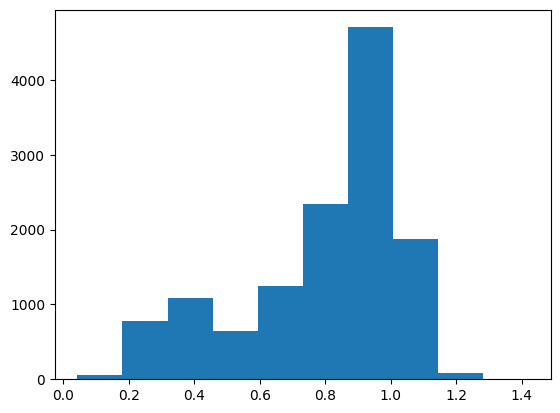

In [ ]:
embed_norm_biggest_frac = []

for i in range(100):
    input = dataset[i]["text"]
    activations_SMPD = get_llm_activations_SMPD(input,
                                                model=llm,
                                                subtract_mean=True)
    feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
    
    
    for sequence_pos in range(128):
        active_features = torch.where(feature_activations_SH[sequence_pos] != 0)[0].to("cpu").numpy()
        embed_norm = [crosscoder.W_dec_HXD[feature,0,0,:].norm()*feature_activations_SH[sequence_pos, feature] for feature in active_features]
        embed_norm_biggest_frac.append(max(embed_norm)/activations_SMPD[sequence_pos, 0, 0, :].norm())

plt.hist(embed_norm_biggest_frac)
plt.show()


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

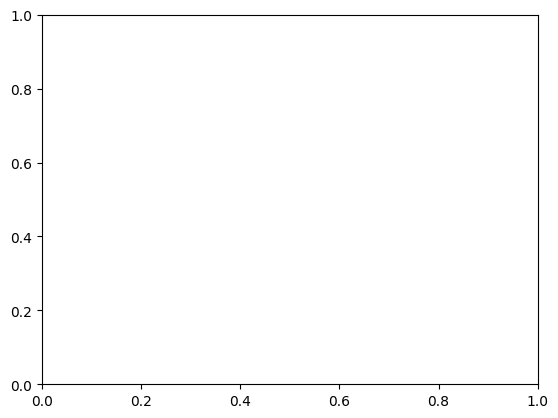

In [23]:
input = dataset[5]["text"]
activations_SMPD = get_llm_activations_SMPD(input,
                                            model=llm,
                                            subtract_mean=True)
feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
sequence_pos = 90
active_features = torch.where(feature_activations_SH[sequence_pos] != 0)[0].to("cpu").numpy()

# norms = []
# for hookpoint in hookpoints:
#     activations = activations_SMPD[sequence_pos, 0, hookpoints.index(hookpoint), :]
#     dataloader_mean = dataloader_mean_SMPD[sequence_pos, 0, hookpoints.index(hookpoint), :]
#     norms.append((activations).norm())
# plt.plot(norms)
# plt.show()

# Get the 10 most important features by activation magnitude
top_features = sorted(active_features, 
                     key=lambda f: abs(feature_activations_SH[sequence_pos, f].item()),
                     reverse=True)[:10]

# Plot norms for each feature with different colors and add legend
for feature in active_features:
    norms = []
    for i in range(5):
        decoder_column = crosscoder.W_dec_HXD[feature,0,4*i,:]
        norms.append(decoder_column.norm() * feature_activations_SH[sequence_pos, feature] / activations_SMPD[sequence_pos, 0, 4*i, :].norm())
    
    if feature in top_features:
        plt.plot(norms, label=f"Feature {feature}")
    else:
        plt.plot(norms, color='gray', alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot norms for each feature with different colors and add legend
for feature in active_features:
    norms = []
    for i in range(5):
        encode_term = torch.dot(activations_SMPD[sequence_pos, 0, 4*i, :], crosscoder.W_enc_XDH[0, 4*i, :, feature])
        encode_term *= crosscoder.W_dec_HXD[feature,0,[0,4,8,12,16],:].norm()
        norms.append(encode_term)
    
    if feature in top_features:
        plt.plot(norms, label=f"Feature {feature}")
    else:
        plt.plot(norms, color='gray', alpha=0.3)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Features: Dialogue, Foreshadowing Summary: Two brothers, Tim and Sam, played pretend heroes with a toy gun until a real bad guy threatened them. Their neighbor, Mrs. Lee, saved them with a broom and called the police. They gave Mrs. Lee their toy gun and promised to never play with guns again. Words: mention, gun, strong 
Story:   Tim and Sam were brothers who liked to play pretend. They had a toy gun that made a loud noise when they pulled the trigger. They liked to pretend they were strong heroes who fought bad guys. One day, they were playing in the backyard when they heard a knock on the door. It was their neighbor, Mrs. Lee, who was very old and kind. She brought them some cookies and asked them what they were playing. "We are strong heroes, Mrs. Lee," Tim said. "We have a gun and we can stop any bad guys." "That sounds like fun," Mrs. Lee said. "But be careful with that gun, boys. It might scare someone who doesn't know it's a toy." "OK, Mrs. Lee, we will," Sam said. "Thank you f

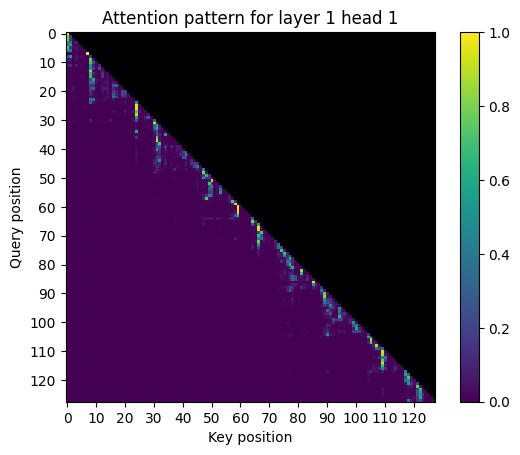

In [31]:
input = dataset[0]["text"]
print(input)
tokens = torch.tensor(tokenizer.encode(input)[0:128])
_, cache = llm.run_with_cache(tokens.unsqueeze(0),
                              names_filter=hookpoints + ["blocks.1.attn.hook_q",
                                                        "blocks.1.attn.hook_k",
                                                        "blocks.1.attn.hook_attn_scores"])

head = 1
activations_SMPD = get_llm_activations_SMPD(input,
                                            model=llm,
                                            subtract_mean=True)
feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
decode_SMPD = crosscoder._decode_BXD(feature_activations_SH) + dataloader_mean_SMPD[0:tokens.shape[0],0,:,:].unsqueeze(1)
cache_attention_input_SD = cache['blocks.1.ln1.hook_normalized'][0]
print((decode_SMPD[:,:,hookpoints.index('blocks.1.ln1.hook_normalized'),:].squeeze() - cache_attention_input_SD).norm())
print(cache_attention_input_SD.norm())

attention_scores = attention_pattern_QK(1,
                                        head,
                                        cache_attention_input_SD,
                                        True,
                                        cache_attention_input_SD,
                                        True)
attention_scores = lower_triangular_mask(attention_scores)
cache_attn_scores = cache['blocks.1.attn.hook_attn_scores'][0,head,:,:]
cache_attn_scores = lower_triangular_mask(cache_attn_scores.to("cpu").numpy())
print(np.linalg.norm(attention_scores-cache_attn_scores))
print(np.linalg.norm(attention_scores))

softmaxed_attention_scores = softmax_pattern(attention_scores)
softmaxed_cache_attn_scores = softmax_pattern(cache_attn_scores)
print(np.linalg.norm(softmaxed_attention_scores-softmaxed_cache_attn_scores))
print(np.linalg.norm(softmaxed_attention_scores))

plot_attention_pattern(softmaxed_attention_scores, f"Attention pattern for layer 1 head {head}")

In [24]:
display_feature_activations_where_active(490, number_examples=8)

[0, 1, 2, 3, 4, 5, 6, 7]


In [25]:
input = dataset[0]["text"]
tokens = torch.tensor(tokenizer.encode(input)[0:128])
print([(i, tokenizer.decode([tokens[i]])) for i in range(128)])

[(0, 'Features'), (1, ':'), (2, ' Dialogue'), (3, ','), (4, ' Fore'), (5, 'shadow'), (6, 'ing'), (7, ' Summary'), (8, ':'), (9, ' Two'), (10, ' brothers'), (11, ','), (12, ' Tim'), (13, ' and'), (14, ' Sam'), (15, ','), (16, ' played'), (17, ' pretend'), (18, ' heroes'), (19, ' with'), (20, ' a'), (21, ' toy'), (22, ' gun'), (23, ' until'), (24, ' a'), (25, ' real'), (26, ' bad'), (27, ' guy'), (28, ' threatened'), (29, ' them'), (30, '.'), (31, ' Their'), (32, ' neighbor'), (33, ','), (34, ' Mrs'), (35, '.'), (36, ' Lee'), (37, ','), (38, ' saved'), (39, ' them'), (40, ' with'), (41, ' a'), (42, ' broom'), (43, ' and'), (44, ' called'), (45, ' the'), (46, ' police'), (47, '.'), (48, ' They'), (49, ' gave'), (50, ' Mrs'), (51, '.'), (52, ' Lee'), (53, ' their'), (54, ' toy'), (55, ' gun'), (56, ' and'), (57, ' promised'), (58, ' to'), (59, ' never'), (60, ' play'), (61, ' with'), (62, ' guns'), (63, ' again'), (64, '.'), (65, ' Words'), (66, ':'), (67, ' mention'), (68, ','), (69, ' gu

#### Observations
Replacing crosscoder encodings with average feature strengths conditional on being active doesn't make much difference -- that is, the set of active features is encoding most of the information, the precise strengths are often quite close to average.

Fundamental idea of compact proofs perspective - decompose the preacts and postacts into a share for each feature, then try to predict these feature by feature -- that is, if we just know a single feature's activation can we predict its share of the postactivations? Which in practice means, looking just at a single feature's activation can we predict the sign of the neuron's preactivation?

Most MLP neurons are turned off (90-90%).
If we just look at a single feature + the mean, that hardly helps predict the sign of the neuron's preactivation, compared to just assuming it'll be negative.

6.119140625
[1094  832  700  512 1230  104  754  367  672  718  852  250 1469 1218
  252 1121 1180  783  333  228]
tensor(-0.2114, device='cuda:0')
[-1.70379224  1.41384702  1.34523943 -1.33628318  1.32594827 -1.266558
  1.24652699  1.24542129 -1.24511945 -1.22661647 -1.22646866  1.22597381
 -1.22308895 -1.14534212  1.13893451  1.13160658 -1.12897873  1.12091826
 -1.12061224  1.08103949]
290.81793655246986


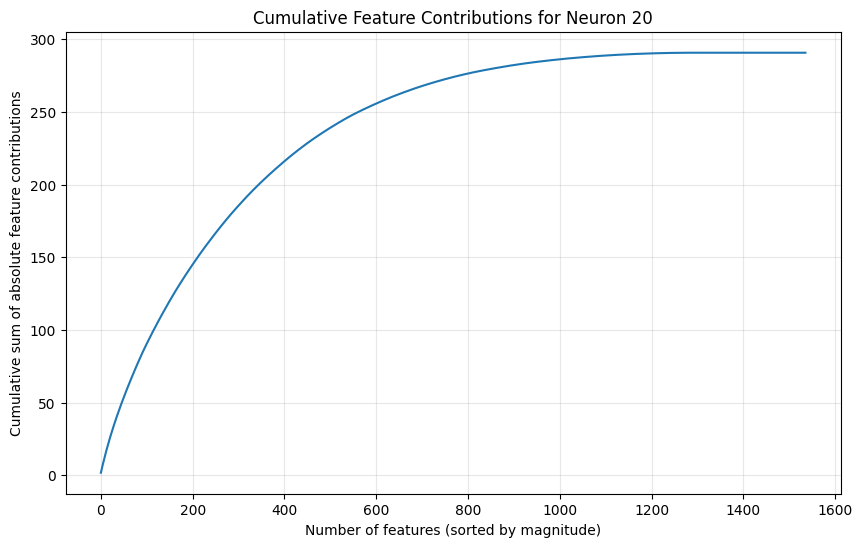

In [26]:
from sleepers.analysis.ft_analysis_util import display_feature_activation_visualization

sequence_pos = 2

input = dataset[1]["text"]
tokens = torch.tensor(tokenizer.encode(input)[0:128])
_, cache = llm.run_with_cache(tokens.unsqueeze(0),
                              names_filter=hookpoints+[f"blocks.{layer}.hook_mlp_out"])
activations_SMPD = get_llm_activations_SMPD(input,
                                            model=llm,
                                            subtract_mean=True)
feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
decode_SMPD = crosscoder._decode_BXD(feature_activations_SH) + dataloader_mean_SMPD[0:tokens.shape[0],0,:,:].unsqueeze(1)
decode_mlp_input_SD = decode_SMPD[:,0,hookpoints.index(f'blocks.{layer}.ln2.hook_normalized'),:]
decode_mlp_preact_SU = decode_mlp_input_SD @ W_in + b_in

mean_at_mlp_input_SU = dataloader_mean_SMPD[:,0,hookpoints.index(f"blocks.{layer}.ln2.hook_normalized"),:] @ W_in + b_in
features_at_mlp_input_HU = crosscoder.W_dec_HXD[:,0,hookpoints.index(f"blocks.{layer}.ln2.hook_normalized"),:] @ W_in
features_at_mlp_input_HU = features_at_mlp_input_HU.to("cpu").numpy() * feature_activations_active_mean[:, np.newaxis]

incorrect_sign_predictions = 0
for neuron in range(llm.cfg.d_mlp):
    mean_at_neuron_S = mean_at_mlp_input_SU[:,neuron]
    mean_at_neuron = mean_at_neuron_S[sequence_pos].item()
    active_features = torch.where(feature_activations_SH[sequence_pos] != 0)[0].to("cpu").numpy()
    active_features_data_indep = features_at_mlp_input_HU[active_features, neuron]
    active_features_data_dep = feature_activations_SH[sequence_pos, active_features].to("cpu").numpy()/feature_activations_active_mean[active_features]
    active_features_total = active_features_data_dep * active_features_data_indep
    total = sum(active_features_total) + mean_at_neuron
    per_feature_incorrect_sign_predictions = (active_features_total + mean_at_neuron)*total < 0
    # print(sum(active_features_data_dep) + mean_at_neuron_S[sequence_pos])
    # print(total)
    # print(decode_mlp_preact_SU[sequence_pos, neuron]) # same as total
    incorrect_sign_predictions += sum(per_feature_incorrect_sign_predictions)
print(incorrect_sign_predictions/llm.cfg.d_mlp)

neuron = 20
data_indep_top_features = np.argsort(-1.0*np.abs(features_at_mlp_input_HU[:, neuron]))
print(data_indep_top_features[0:20])
print(mean_at_neuron_S[sequence_pos])
print(features_at_mlp_input_HU[data_indep_top_features[:20], neuron])
print(sum(np.abs(features_at_mlp_input_HU[:, neuron])))
# Plot cumulative sum of sorted feature contributions
plt.figure(figsize=(10,6))
cumsum = np.cumsum(np.abs(features_at_mlp_input_HU[data_indep_top_features, neuron]))
plt.plot(range(len(cumsum)), cumsum)
plt.xlabel('Number of features (sorted by magnitude)')
plt.ylabel('Cumulative sum of absolute feature contributions')
plt.title(f'Cumulative Feature Contributions for Neuron {neuron}')
plt.grid(True, alpha=0.3)
plt.show()

# print(features_at_mlp_input_HU[data_indep_top_features, neuron])
# for sequence_pos in range(128):
#     mean_at_neuron_S = mean_at_mlp_input_SU[:,neuron]
#     active_features = torch.where(feature_activations_SH[sequence_pos] != 0)[0].to("cpu").numpy()
#     active_features_data_indep = features_at_mlp_input_HU[active_features, neuron]
#     active_features_data_dep = feature_activations_SH[sequence_pos, active_features].to("cpu").numpy()/feature_activations_active_mean[active_features]
#     active_features_total = active_features_data_dep * active_features_data_indep
#     total = sum(active_features_total) + mean_at_neuron_S[sequence_pos]
#     top_feature_index = np.argmax(np.abs(active_features_total))
#     top_feature = active_features[top_feature_index]
#     abs_sum = sum(np.abs(active_features_total)) + np.abs(mean_at_neuron_S[sequence_pos].to("cpu").numpy())
#     if np.abs(active_features_total[top_feature_index].item()) > np.abs(mean_at_neuron_S[sequence_pos].item()):
#         print(top_feature)
#         print(np.abs(active_features_total[top_feature_index].item())/abs_sum.item())
#     else:
#         print("mean")
#         print(np.abs(mean_at_neuron_S[sequence_pos].item())/abs_sum.item())

-0.08881558383024268
[0.9763637185096741]
[0.9156941175460815, 0.9713412523269653, 0.8859717845916748, 0.982829749584198, 1.001059889793396, 1.0260108709335327, 0.9278435111045837, 1.0500824451446533, 1.0907546281814575, 0.9451462030410767, 1.047350525856018, 0.8489379286766052, 1.0048636198043823, 1.0056272745132446, 1.0209521055221558, 1.0384782552719116, 1.0329086780548096, 1.0234476327896118, 1.0184452533721924, 1.0009210109710693, 1.0338214635849, 1.0238407850265503, 1.0126757621765137, 1.0616949796676636, 1.0264064073562622, 0.8648301362991333, 1.0799760818481445, 0.9159502983093262, 0.9837678670883179, 0.9386832118034363, 1.0424602031707764, 1.0471692085266113, 1.0093761682510376, 1.0239903926849365, 1.0078703165054321, 1.0888198614120483, 1.1219899654388428, 0.9664176106452942, 1.0085325241088867, 1.1306402683258057, 1.0922324657440186, 1.028582215309143, 1.0131276845932007, 1.005021095275879, 0.9802964925765991, 0.9688315391540527, 1.0224764347076416, 0.9660499691963196, 1.017

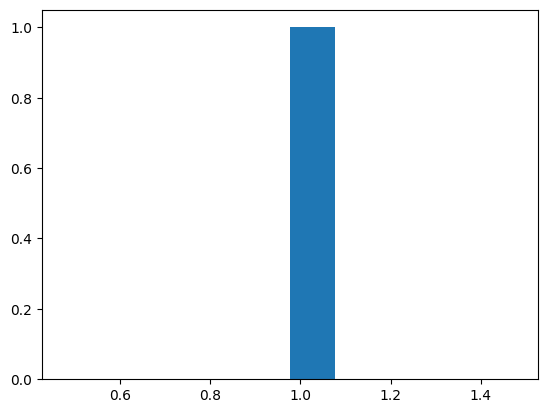

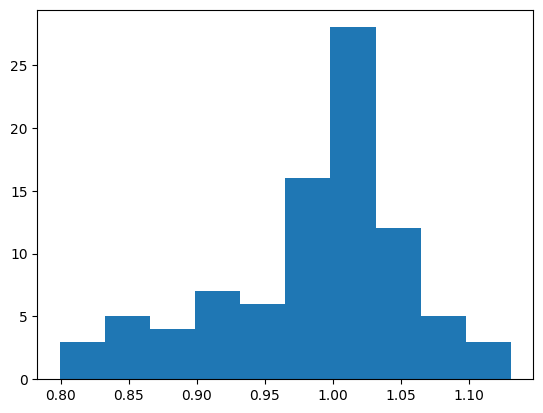

0.011111111111111112
1 89


In [27]:
feature = 396
neuron = 27
print(features_at_mlp_input_HU[feature, neuron])

feature_activation_neuron_negative = []
feature_activation_neuron_positive = []
guessed_wrong = 0
for i in range(400):
    input = dataset[i]["text"]

    activations_SMPD = get_llm_activations_SMPD(input,
                                                model=llm,
                                                subtract_mean=True)

    feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
    decode_SMPD = crosscoder._decode_BXD(feature_activations_SH) + dataloader_mean_SMPD[0:activations_SMPD.shape[0],:,:,:]
    decode_mlp_input_SD = decode_SMPD[:,0,hookpoints.index(f'blocks.{layer}.ln2.hook_normalized'),:]
    mlp_preactivations_SU = decode_mlp_input_SD @ W_in + b_in

    feature_activations_normalised_S = feature_activations_SH[:,feature].to("cpu").numpy()/feature_activations_active_mean[feature]

    for sequence_pos in np.where(feature_activations_normalised_S != 0)[0]:
        guess = feature_activations_normalised_S[sequence_pos]*features_at_mlp_input_HU[feature, neuron] + mean_at_neuron_S[sequence_pos]
        if guess * mlp_preactivations_SU[sequence_pos, neuron] < 0:
            guessed_wrong += 1
        if mlp_preactivations_SU[sequence_pos, neuron] < 0:
            feature_activation_neuron_negative.append(feature_activations_normalised_S[sequence_pos].item())
        else:
            feature_activation_neuron_positive.append(feature_activations_normalised_S[sequence_pos].item())

print(feature_activation_neuron_positive)
print(feature_activation_neuron_negative)
plt.hist(feature_activation_neuron_positive)
plt.show()
plt.hist(feature_activation_neuron_negative)
plt.show()
print(guessed_wrong/(len(feature_activation_neuron_positive) + len(feature_activation_neuron_negative)))
print(len(feature_activation_neuron_positive), len(feature_activation_neuron_negative))


In [28]:
from tqdm import tqdm

layer = 1
neuron = 28

feature_positive_seen = np.zeros(crosscoder.hidden_dim)
feature_negative_seen = np.zeros(crosscoder.hidden_dim)

for i in tqdm(range(50000), desc="Computing feature signs seen"):
    input = dataset[i]["text"]

    activations_SMPD = get_llm_activations_SMPD(input,
                                                model=llm,
                                                subtract_mean=True)

    feature_activations_SH = crosscoder._encode_BH(activations_SMPD)
    decode_SMPD = crosscoder._decode_BXD(feature_activations_SH) + dataloader_mean_SMPD[0:activations_SMPD.shape[0],:,:,:]
    decode_mlp_input_SD = decode_SMPD[:,0,hookpoints.index(f'blocks.{layer}.ln2.hook_normalized'),:]
    mlp_preactivations_SU = decode_mlp_input_SD @ W_in + b_in
    
    for sequence_pos in range(activations_SMPD.shape[0]):
        active_features = torch.where(feature_activations_SH[sequence_pos] != 0)[0].to("cpu").numpy()
        preact = mlp_preactivations_SU[sequence_pos, neuron] 
        if preact > 0:
            feature_positive_seen[active_features] += 1
        else:
            feature_negative_seen[active_features] += 1

Computing feature signs seen:   0%|          | 5/50000 [00:00<18:33, 44.89it/s]

Computing feature signs seen: 100%|██████████| 50000/50000 [18:42<00:00, 44.53it/s]


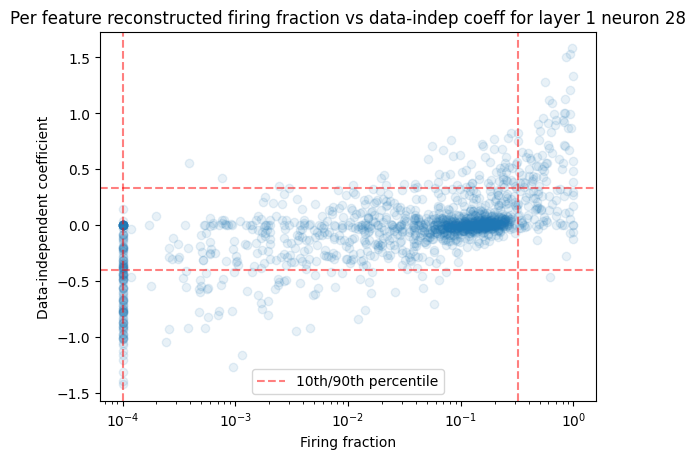

0.10592592592592592


In [44]:
frac_positive = []
importance = []
for feature in range(crosscoder.hidden_dim):
    if feature_positive_seen[feature] + feature_negative_seen[feature] > 1000:
        frac_positive.append(feature_positive_seen[feature]/(feature_positive_seen[feature] + feature_negative_seen[feature]))
        importance.append(features_at_mlp_input_HU[feature, neuron])

eps = 1e-4
frac_positive_eps = [max(x, eps) for x in frac_positive]

# Calculate 10th and 90th percentiles
x_10th = np.percentile(frac_positive_eps, 10)
x_90th = np.percentile(frac_positive_eps, 90)
y_10th = np.percentile(importance, 10)
y_90th = np.percentile(importance, 90)

plt.scatter(frac_positive_eps, importance, alpha=0.1)
plt.xlabel('Firing fraction')
plt.ylabel('Data-independent coefficient')
plt.xscale('log')

# Add percentile lines
plt.axvline(x=x_10th, color='r', linestyle='--', alpha=0.5, label='10th/90th percentile')
plt.axvline(x=x_90th, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=y_10th, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=y_90th, color='r', linestyle='--', alpha=0.5)

plt.title(f"Per feature reconstructed firing fraction vs data-indep coeff for layer {layer} neuron {neuron}")

plt.legend()
plt.show()
print(len([_ for x in frac_positive if x < eps])/len(frac_positive))

In [42]:
print(mean_at_mlp_input_SU[40, neuron])

tensor(-0.9878, device='cuda:0')


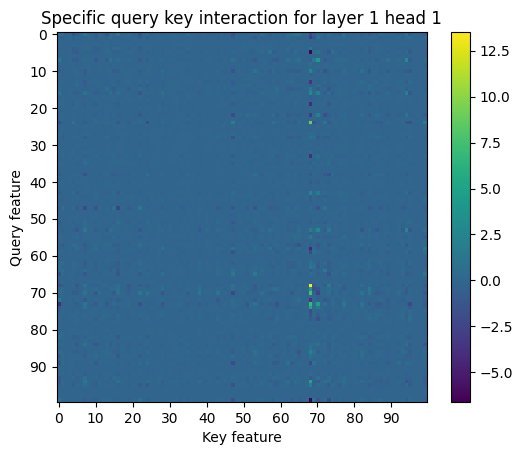

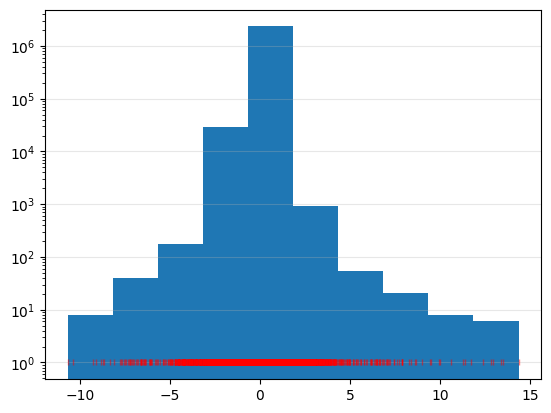

[(1037, 68), (68, 68), (1037, 615), (68, 615), (615, 68)]
Query feature: 1037, Key feature: 68, interaction strength: 14.354323387145996
[1, 3]


[0, 2]


Query feature: 68, Key feature: 68, interaction strength: 13.502885818481445
[0, 2]


[0, 2]


Query feature: 1037, Key feature: 615, interaction strength: 13.40140438079834
[1, 3]


[11, 19]


Query feature: 68, Key feature: 615, interaction strength: 12.912343978881836
[0, 2]


[11, 19]


Query feature: 615, Key feature: 68, interaction strength: 12.827282905578613
[11, 19]


[0, 2]


In [29]:
from sleepers.analysis.ft_analysis_util import display_feature_activation_visualization

layer = 1
head = 1

activations = crosscoder.W_dec_HXD[:,0,hookpoints.index(f"blocks.{layer}.ln1.hook_normalized"),:]

attention_scores = attention_pattern_QK(
    layer,
    head,
    activations, False,
    activations, False)
attention_scores *= feature_activations_active_mean[np.newaxis, :]
attention_scores *= feature_activations_active_mean[:, np.newaxis]
plot_attention_pattern(attention_scores[:100, :100], f"Specific query key interaction for layer {layer} head {head}", xlabel='Key feature', ylabel='Query feature')

plt.hist(attention_scores.flatten())
plt.yscale('log')
plt.gca().yaxis.grid(True, alpha=0.3)
# Add rug plot at the bottom
plt.gca().plot(attention_scores.flatten(), np.ones_like(attention_scores.flatten()), '|', color='red', alpha=0.5, markersize=5)
plt.show()

top_interactions = []
attention_scores_copy = attention_scores.copy()
for _ in range(5):
    top_interaction = np.unravel_index(np.argmax(np.abs(attention_scores_copy)), attention_scores_copy.shape)
    top_interaction = (top_interaction[0].item(), top_interaction[1].item())
    top_interactions.append(top_interaction)
    attention_scores_copy[top_interaction] = 0
print(top_interactions)

for q, k in top_interactions:
    print(f"Query feature: {q}, Key feature: {k}, interaction strength: {attention_scores[q, k]}")
    display_feature_activations_where_active(q)
    display_feature_activations_where_active(k)

Think about analysing "induction/duplicate token heads" like layer 1 head 0. Primary contribution comes from specific key / positional query pattern.

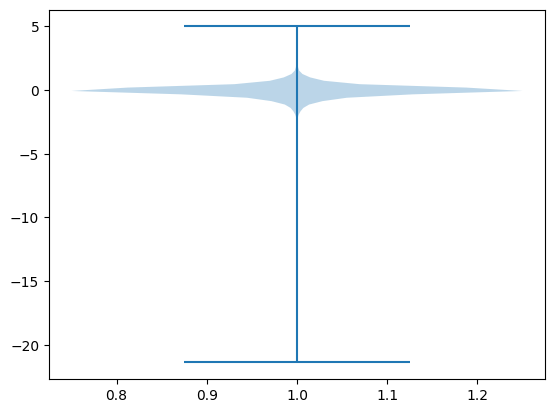

Feature: 68, strength: -21.39063684522459


Feature: 615, strength: -19.791081379535566


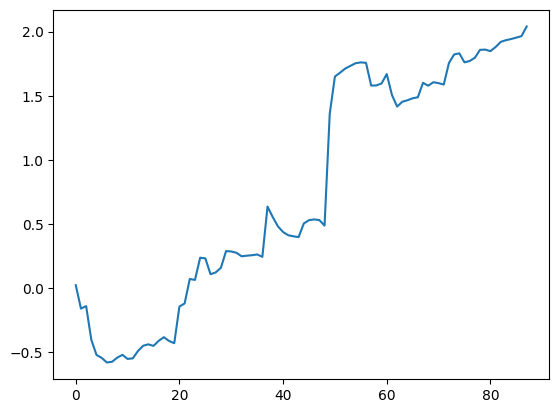

In [76]:
from sleepers.analysis.ft_analysis_util import display_feature_activation_visualization

layer = 1
head = 1

activations = crosscoder.W_dec_HXD[:,0,hookpoints.index(f"blocks.{layer}.ln1.hook_normalized"),:]
mean_input_SD = dataloader_mean_SMPD[:,0,hookpoints.index(f"blocks.{layer}.ln1.hook_normalized"),:]

attention_scores = attention_pattern_QK(
    layer,
    head,
    mean_input_SD, True,
    activations, False)
attention_scores = np.mean(attention_scores, axis=0)
mean_adjusted_attention_scores = attention_scores*feature_activations_active_mean
# Plot distribution of attention scores with violin plot
plt.violinplot(mean_adjusted_attention_scores)
plt.show()

top_features = np.argsort(-1.0*np.abs(mean_adjusted_attention_scores))[:2]
example_texts = [dataset[i]["text"] for i in range(100)]
example_llm_activations = [get_llm_activations_SMPD(text, subtract_mean=True) for text in example_texts]
example_activations = [crosscoder._encode_BH(activations) for activations in example_llm_activations]
for f in top_features:
    print(f"Feature: {f}, strength: {mean_adjusted_attention_scores[f]}")
    # only include texts where feature is active at some sequence point
    texts_idxs = [i for i, acts in enumerate(example_activations) if acts[:, f].sum() > 0]
    texts_idxs = texts_idxs[:1]
    if len(texts_idxs) > 0:
        display(display_feature_activation_visualization(
            tokenizer,
            [example_texts[i] for i in texts_idxs],
            [example_activations[i] for i in texts_idxs],
            feature_index=f))
    else:
        print("No examples found with non-zero activation")

# Double check reconstruction
activations_SMLD = get_llm_activations_SMPD(input,
                                            model=llm,
                                            subtract_mean=True)
feature_activations = crosscoder._encode_BH(activations_SMLD)[57]
active_features = torch.where(feature_activations != 0)[0]
activation = 0
acts = []
for feature in active_features:
    # print((feature_activations[feature].to("cpu").numpy().item(), attention_scores[feature].item()))
    activation += feature_activations[feature].to("cpu").numpy()*attention_scores[feature]
    acts.append(activation)
# line plot of how activation changes as we account for each feature
plt.plot(acts)
plt.show()



Most significant correction comes from pairs of query and key features.

interaction_matrix_unscaled shape: (1536,)
interaction_matrix_unscaled shape: (34, 27)
Top interaction: 782 (14) -> 4 (0)
Query feature average activation: 44.71612358093262
Query feature activation here: 49.35680389404297
Key feature average activation: 26.566743781349874
Key feature activation here: 26.60235595703125
Data independent interaction strength: 0.691947877407074
Interaction strength: 0.764782726764679 out of overall 1.9537745825271315


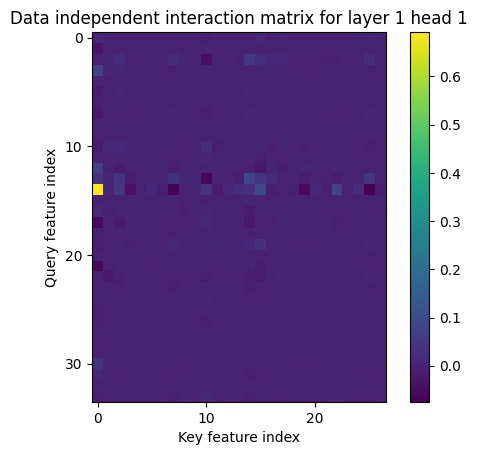

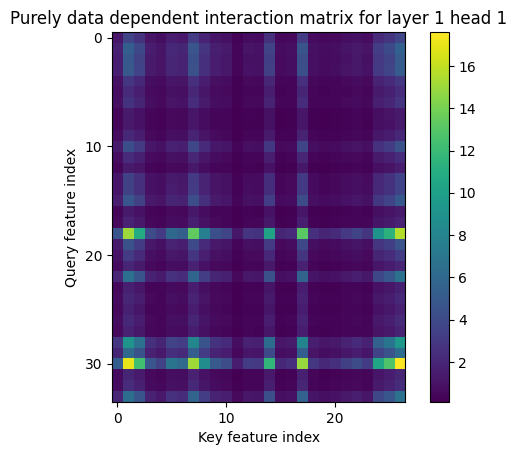

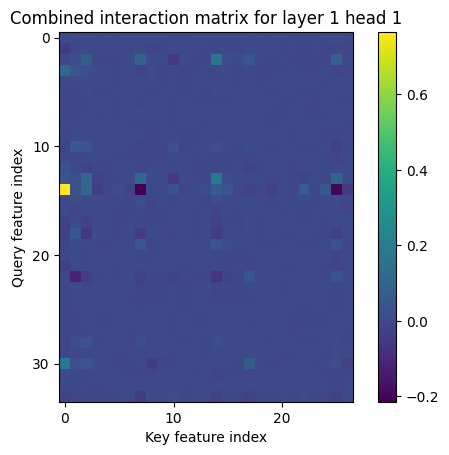

In [39]:
layer = 1
head = 1

query_position = 127#82
key_position = 81

input = dataset[0]["text"]

def feature_query_key_interaction(hidden_activations, layer, head, query_position, key_position):
	feature_activations_query = hidden_activations[query_position]
	query_active_features = torch.where(feature_activations_query != 0)[0]
	feature_activations_key = hidden_activations[key_position]
	key_active_features = torch.where(feature_activations_key != 0)[0]
	query_activations_for_features = crosscoder.W_dec_HXD[query_active_features, 0, hookpoints.index(f"blocks.{layer}.ln1.hook_normalized")]
	key_activations_for_features = crosscoder.W_dec_HXD[key_active_features, 0, hookpoints.index(f"blocks.{layer}.ln1.hook_normalized")]
	interaction_matrix_unscaled = attention_pattern_QK(
		layer, head,
		query_activations_for_features, False,
		key_activations_for_features, False)
	query_active_features = query_active_features.cpu().numpy()
	key_active_features = key_active_features.cpu().numpy()
	matrix_scaling = feature_activations_query[query_active_features].unsqueeze(1) * feature_activations_key[key_active_features].unsqueeze(0)
	matrix_scaling = matrix_scaling.to("cpu").numpy()
	print(f'interaction_matrix_unscaled shape: {feature_activations_active_mean.shape}')
	
	interaction_matrix_unscaled *= feature_activations_active_mean[query_active_features][:, np.newaxis]
	interaction_matrix_unscaled *= feature_activations_active_mean[key_active_features][np.newaxis, :]
	print(f'interaction_matrix_unscaled shape: {interaction_matrix_unscaled.shape}')
	
	matrix_scaling /= feature_activations_active_mean[query_active_features][:, np.newaxis]
	matrix_scaling /= feature_activations_active_mean[key_active_features][np.newaxis, :]
	return query_active_features, key_active_features, interaction_matrix_unscaled, matrix_scaling

activations_SMPD = get_llm_activations_SMPD(input,
											model=llm,
											subtract_mean=True)
hidden_activations = crosscoder._encode_BH(activations_SMPD)
query_active_features, key_active_features, interaction_matrix_unscaled, matrix_scaling = feature_query_key_interaction(hidden_activations, layer, head, query_position, key_position)
interaction_matrix = interaction_matrix_unscaled*matrix_scaling
# Find q, k index of highest activation in interaction matrix
top_interaction = np.unravel_index(np.argmax(np.abs(interaction_matrix)), interaction_matrix.shape)
query_top = query_active_features[top_interaction[0]].item()
key_top = key_active_features[top_interaction[1]].item()
print(f"Top interaction: {query_top} ({top_interaction[0]}) -> {key_top} ({top_interaction[1]})")
print(f"Query feature average activation: {feature_activations_active_mean[query_top].item()}")
print(f"Query feature activation here: {hidden_activations[query_position][query_top].item()}")
print(f"Key feature average activation: {feature_activations_active_mean[key_top].item()}")
print(f"Key feature activation here: {hidden_activations[key_position][key_top].item()}")
print(f"Data independent interaction strength: {interaction_matrix_unscaled[top_interaction].item()}")
print(f"Interaction strength: {interaction_matrix[top_interaction].item()} out of overall {sum(interaction_matrix.flatten())}")

example_texts = [input]# + [dataset[i]["text"] for i in range(2)]
example_llm_activations = [get_llm_activations_SMPD(text, subtract_mean=True) for text in example_texts]
example_activations = [crosscoder._encode_BH(activations) for activations in example_llm_activations]
display(display_feature_activation_visualization(tokenizer, example_texts, example_activations, feature_index=query_top))
display(display_feature_activation_visualization(tokenizer, example_texts, example_activations, feature_index=key_top))

plot_attention_pattern(interaction_matrix_unscaled, f"Data independent interaction matrix for layer {layer} head {head}", xlabel='Key feature index', ylabel='Query feature index')
plot_attention_pattern(matrix_scaling, f"Purely data dependent interaction matrix for layer {layer} head {head}", xlabel='Key feature index', ylabel='Query feature index')
plot_attention_pattern(interaction_matrix, f"Combined interaction matrix for layer {layer} head {head}", xlabel='Key feature index', ylabel='Query feature index')


In [71]:
q = 23
k = 0
print(interaction_matrix_unscaled[q, k])
print(interaction_matrix[q, k])
q_feat = query_active_features[q]
k_feat = key_active_features[k]
display(display_feature_activation_visualization(tokenizer, example_texts, example_activations, feature_index=q_feat))
display(display_feature_activation_visualization(tokenizer, example_texts, example_activations, feature_index=k_feat))

0.27419898
0.24911207


In [19]:
break

from tqdm import tqdm

dataset_attention_interaction = np.zeros((1536, 1536))
count = 0

texts = [dataset[i]["text"] for i in range(10)]

for input in tqdm(texts, desc="Computing attention interaction matrix", total=len(texts)):
    activations_SMLD = get_llm_activations_SMLD(input,
                                                model=llm,
                                                subtract_mean=True)
    hidden_activations = crosscoder._encode_BH(activations_SMLD)
    for query_pos in range(128):
        for key_pos in range(query_pos+1):
            query_active_features, key_active_features, interaction_matrix_unscaled, matrix_scaling = feature_query_key_interaction(hidden_activations, layer, head, query_pos, key_pos)
            interaction_matrix = interaction_matrix_unscaled*matrix_scaling
            query_active_features = query_active_features.cpu().numpy()
            key_active_features = key_active_features.cpu().numpy()
            dataset_attention_interaction[np.ix_(query_active_features, key_active_features)] += interaction_matrix
            count += 1
dataset_attention_interaction = dataset_attention_interaction/count

SyntaxError: 'break' outside loop (677288411.py, line 1)

In [79]:
break

interactions = np.abs(dataset_attention_interaction).flatten()
# plot graph showing the fraction of the sum of `interactions` contributed by the first x percent
interactions_cumsum = np.cumsum(sorted(interactions, reverse=True))
plt.plot(interactions_cumsum/interactions_cumsum[-1])
plt.xscale('log')
plt.show()
print(sorted(interactions, reverse=True)[:200])
# Looks like we need about 90% of feature pairs to get to 80% of total interaction.
# Though potentially a lot of this is basically noise, not sure how to tell.

SyntaxError: 'break' outside loop (3418571925.py, line 1)

In [80]:
break

top_interactions = []
attention_scores_copy = dataset_attention_interaction.copy()
for i in range(2):
    top_interaction = np.unravel_index(np.argmax(np.abs(attention_scores_copy)), attention_scores_copy.shape)
    top_interaction = (top_interaction[0].item(), top_interaction[1].item())
    top_interactions.append(top_interaction)
    attention_scores_copy[top_interaction] = 0
print(top_interactions)

from sleepers.analysis.ft_analysis_util import display_feature_activation_visualization
example_texts = [dataset[i]["text"] for i in range(100)]
example_llm_activations = [get_llm_activations_SMLD(text, subtract_mean=True) for text in example_texts]
example_activations = [crosscoder._encode_BH(activations) for activations in example_llm_activations]
for q, k in top_interactions:
    print(f"Query feature: {q}, Key feature: {k}, interaction strength: {dataset_attention_interaction[q, k]}")
    # only include texts where feature is active at some sequence point
    texts_q_idxs = [i for i, acts in enumerate(example_activations) if acts[:, q].sum() > 1]
    texts_q_idxs = texts_q_idxs[:1]
    if len(texts_q_idxs) > 0:
        display(display_feature_activation_visualization(
            tokenizer,
            [example_texts[i] for i in texts_q_idxs],
            [example_activations[i] for i in texts_q_idxs],
            feature_index=q))
    else:
        print("No examples found with non-zero activation")
    texts_k_idxs = [i for i, acts in enumerate(example_activations) if acts[:, k].sum() > 0]
    texts_k_idxs = texts_k_idxs[:1]
    if len(texts_k_idxs) > 0:
        display(display_feature_activation_visualization(
            tokenizer,
            [example_texts[i] for i in texts_k_idxs],
            [example_activations[i] for i in texts_k_idxs],
            feature_index=k))
    else:
        print("No examples found with non-zero activation")

SyntaxError: 'break' outside loop (1367329278.py, line 1)

In [82]:
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

layer = 1
head = 1

input = dataset[0]["text"]
tokens = torch.tensor(tokenizer.encode(input)[0:128])
_, attn_cache = llm.run_with_cache(tokens.unsqueeze(0), names_filter=[
    f"blocks.{layer}.attn.hook_q",
    f"blocks.{layer}.attn.hook_k",
    f"blocks.{layer}.attn.hook_attn_scores"
])
cache_attn_scores = attn_cache[f'blocks.{layer}.attn.hook_attn_scores'][0,head,:,:]
cache_attn_scores = lower_triangular_mask(cache_attn_scores.to("cpu").numpy())

def update_display(q_idx, tokens, feature_activations_SH):
    with output_area:
        output_area.clear_output(wait=True)
        # For the selected token q_idx, get its attention scores for all tokens 0...q_idx.
        # cache_attn_scores is assumed to be a NumPy array of shape (sequence_length, sequence_length)
        attn_scores = cache_attn_scores[q_idx, :q_idx+1]
        # compute softmax of attn_scores
        attn_scores_softmax = np.exp(attn_scores) / np.sum(np.exp(attn_scores))
        # Normalize the attention values for tokens 0...q_idx for color mapping.
        if attn_scores_softmax.size > 0:
            min_val = attn_scores_softmax.min()
            max_val = attn_scores_softmax.max()
            range_val = max_val - min_val if max_val - min_val != 0 else 1.0
            norm_attn = (attn_scores_softmax - min_val) / range_val
        else:
            norm_attn = attn_scores_softmax

        # Build an HTML string to show the full input text (tokens) with background color for tokens 0...q_idx.
        # The intensity of the red color corresponds to the normalized attention weight.
        html_str = f"<div style='margin-bottom:8px;'><b>Layer {layer} head {head} attention for token {q_idx}</b></div>"
        for i, token in enumerate(tokens):
            if i <= q_idx:
                # Use the normalized attention value (between 0 and 1) to set the red intensity.
                # Higher attention → more opaque red.
                alpha = norm_attn[i] if i < len(norm_attn) else 0.0
                
                # Add a distinctive border for the clicked token
                if i == q_idx:
                    style = f"background-color: rgba(255, 0, 0, {alpha}); padding:2px; margin:2px; border: 3px solid blue; border-radius: 5px;"
                else:
                    style = f"background-color: rgba(255, 0, 0, {alpha}); padding:2px; margin:2px;"
            else:
                style = "padding:2px; margin:2px;"
            html_str += f"<span style='{style}'>{tokenizer.decode([token])}</span> "
        display(HTML(html_str))
        
        # Create a color mapping scale
        fig, ax = plt.subplots(figsize=(6, 0.5))
        plt.title('Attention Weight Color Scale')
        cmap = cm.Reds
        norm = plt.Normalize(min_val, max_val)
        cb = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), 
                          cax=ax, 
                          orientation='horizontal')
        cb.set_label('Attention Weight')
        plt.show()

# Create a clickable button for each token.
# (It is assumed that 'tokens' is a list of token strings for the input.)
token_buttons = []
for idx, token in enumerate(tokens):
    button = widgets.Button(
        description=tokenizer.decode([token]),
        layout=widgets.Layout(width='auto', margin='2px 2px 2px 2px')
    )
    # Attach the current token index to the button.
    button.token_idx = idx
    # When the button is clicked, call update_display with its token index.
    button.on_click(lambda btn: update_display(btn.token_idx, tokens, feature_activations_SH))
    token_buttons.append(button)

# Display instructions and the tokens as clickable buttons.
display(HTML("<div style='margin:8px 0;'><b>Click on a token below to visualize its attention (from that token back to earlier tokens):</b></div>"))
# Use an HBox with wrapping style to show all tokens inline.
tokens_box = widgets.HBox(token_buttons, layout=widgets.Layout(flex_flow='row wrap', width='100%'))
display(tokens_box)

# Create an output area where the attention visualization (colored input text) will be shown.
output_area = widgets.Output()
display(output_area)


Output()

In [83]:
print([(i, tokenizer.decode(token)) for i, token in enumerate(tokens)])

[(0, 'Features'), (1, ':'), (2, ' Dialogue'), (3, ','), (4, ' Fore'), (5, 'shadow'), (6, 'ing'), (7, ' Summary'), (8, ':'), (9, ' Two'), (10, ' brothers'), (11, ','), (12, ' Tim'), (13, ' and'), (14, ' Sam'), (15, ','), (16, ' played'), (17, ' pretend'), (18, ' heroes'), (19, ' with'), (20, ' a'), (21, ' toy'), (22, ' gun'), (23, ' until'), (24, ' a'), (25, ' real'), (26, ' bad'), (27, ' guy'), (28, ' threatened'), (29, ' them'), (30, '.'), (31, ' Their'), (32, ' neighbor'), (33, ','), (34, ' Mrs'), (35, '.'), (36, ' Lee'), (37, ','), (38, ' saved'), (39, ' them'), (40, ' with'), (41, ' a'), (42, ' broom'), (43, ' and'), (44, ' called'), (45, ' the'), (46, ' police'), (47, '.'), (48, ' They'), (49, ' gave'), (50, ' Mrs'), (51, '.'), (52, ' Lee'), (53, ' their'), (54, ' toy'), (55, ' gun'), (56, ' and'), (57, ' promised'), (58, ' to'), (59, ' never'), (60, ' play'), (61, ' with'), (62, ' guns'), (63, ' again'), (64, '.'), (65, ' Words'), (66, ':'), (67, ' mention'), (68, ','), (69, ' gu

# Code out of date after here, will have many errors!

In [10]:
print(format_tokens_in_examples(top_activations[1480]))

NameError: name 'format_tokens_in_examples' is not defined

[(10, 15.837869644165039), (40, 4.327933311462402), (62, 4.6086859703063965), (69, 31.496246337890625), (83, 6.29663610458374), (299, 14.939373970031738), (373, 4.935280799865723), (427, 10.753364562988281), (554, 5.035945892333984), (764, 4.424668788909912), (790, 7.124403476715088), (872, 11.014476776123047), (938, 4.271945953369141), (968, 10.179426193237305), (1044, 10.85785961151123), (1156, 28.17974090576172), (1186, 23.07332420349121), (1191, 18.850627899169922), (1475, 20.391691207885742), (1480, 16.76771354675293)]


(array([7., 1., 4., 1., 2., 2., 1., 0., 1., 1.]),
 array([ 4.27194595,  6.99437618,  9.71680641, 12.43923569, 15.16166592,
        17.88409615, 20.60652542, 23.3289566 , 26.05138588, 28.77381516,
        31.49624634]),
 <BarContainer object of 10 artists>)

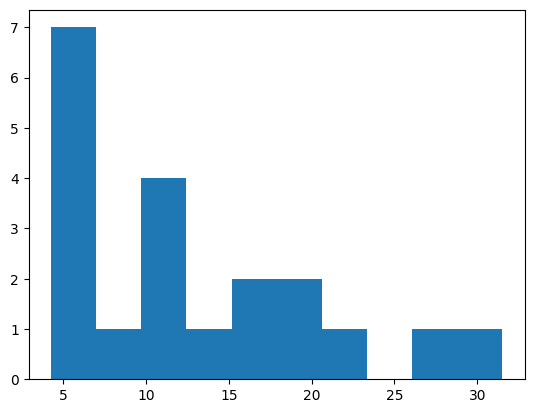

In [11]:
# plot histogram of feature activations at index 10
where = np.where(feature_activations_SH[10,:].cpu().numpy() != 0)[0]
acts = feature_activations_SH[10,feature_activations_SH[10,:] != 0].cpu().numpy()
print(list(zip([int(i) for i in where], [float(f) for f in acts])))
plt.hist(feature_activations_SH[10,feature_activations_SH[10,:] != 0].cpu().numpy())

https://raw.githubusercontent.com/callummcdougall/computational-thread-art/master/example_images/misc/full-merm.svg diagram of hooks and weights

In [15]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 160

q_list = []
k_list = []
v_list = []

activations_BSLD = torch.stack([cache['blocks.0.hook_resid_post'],
                           cache['blocks.1.hook_resid_post'],
                           cache['blocks.2.hook_resid_post'],
                           cache['blocks.3.hook_resid_post']], dim=2)
activations_BSMLD = torch.unsqueeze(activations_BSLD, dim=2)
activations_SMLD = rearrange(activations_BSMLD, "b s m l d -> (b s) m l d")
feature_activations_SH = crosscoder.encode(activations_SMLD)
decode = crosscoder.decode(feature_activations_SH)
# add new feature to represent bias term
feature_activations_SH = torch.cat([feature_activations_SH, torch.ones(feature_activations_SH.shape[0], 1).to(DEVICE)], dim=1)
rec_error = decode.squeeze()-activations_BSLD.squeeze()
print(rec_error.norm(dim=2).square().mean(dim=0))
# Matches expected reconstruction loss summing to ~~300

decode_0 = decode[:,:,0,:].squeeze()

# post_ln1 = llm.blocks[1].ln1.forward(decode_0)
post_ln1 = decode_0 - decode_0.mean(dim=1).unsqueeze(1)
scale = decode_0.pow(2).mean(dim=1).sqrt().unsqueeze(1) # empirically looks fairly constant other than at first token?
post_ln1 = post_ln1/scale

W_Q = llm.blocks[1].attn.W_Q[head]
b_Q = llm.blocks[1].attn.b_Q[head]
W_K = llm.blocks[1].attn.W_K[head]
b_K = llm.blocks[1].attn.b_K[head]
W_V = llm.blocks[1].attn.W_V[head]
b_V = llm.blocks[1].attn.b_V[head]

decode_0_reconstructed = decode_0*0
post_ln1_reconstructed = post_ln1*0
for feature in range(crosscoder.hidden_dim):
    decode_feature = crosscoder.W_dec_HMLD[feature,0,0,:]
    decode_0_reconstructed += decode_feature.unsqueeze(0).repeat(128, 1) * feature_activations_SH[:, feature].unsqueeze(1)
    post_ln1_feature = decode_feature - decode_feature.mean().unsqueeze(0)
    post_ln1_reconstructed += post_ln1_feature.unsqueeze(0).repeat(128, 1)/scale * feature_activations_SH[:, feature].unsqueeze(1)
    q = einsum(W_Q, post_ln1_feature, "d a, d -> a")
    k = einsum(W_K, post_ln1_feature, "d a, d -> a")
    v = einsum(W_V, post_ln1_feature, "d a, d -> a")
    q_list.append(q)
    k_list.append(k)
    v_list.append(v)

crosscoder_bias = crosscoder.b_dec_MLD[0,0,:]
decode_0_reconstructed += crosscoder_bias
bias_post_ln1 = crosscoder_bias - crosscoder_bias.mean().unsqueeze(0)
# empirically seems like bias term not too important here?
post_ln1_reconstructed += bias_post_ln1.unsqueeze(0).repeat(128, 1)/scale
q = einsum(W_Q, bias_post_ln1, "d a, d -> a") + b_Q
k = einsum(W_K, bias_post_ln1, "d a, d -> a") + b_K
v = einsum(W_V, bias_post_ln1, "d a, d -> a") + b_V # TODO these are meaningless without taking the layernorm scale into account
q_list.append(q)
k_list.append(k)
v_list.append(v)

q_list = torch.stack(q_list)
k_list = torch.stack(k_list)
attention_matrix = torch.matmul(q_list, k_list.T) # dimensions query x key
# Plot matrix, labelling the axes query x key
from matplotlib import pyplot as plt
attention_matrix = attention_matrix[:-1,:-1]
vmin = attention_matrix.flatten().min()
vmax = attention_matrix.flatten().max()
feature_importance = attention_matrix.pow(2).sum(dim=0) + attention_matrix.pow(2).sum(dim=1)
feature_order = torch.argsort(feature_importance, descending=True).cpu().numpy()
plt.imshow(attention_matrix.cpu().numpy()[feature_order[:100], feature_order[:100]], cmap='viridis', interpolation='none', vmin=vmin, vmax=vmax)
plt.xlabel('Key')
plt.ylabel('Query')
plt.colorbar()
plt.show()

# Find key features with highest attention
attention_matrix = attention_matrix.cpu().numpy()
top_features = np.argsort(attention_matrix.mean(axis=0))[-5:]
for feature in top_features:
    if feature < crosscoder.hidden_dim:
        print(format_tokens_in_examples(top_activations[feature]))
    else:
        print("Bias feature")

# Find query features with highest attention
top_features = np.argsort(attention_matrix.mean(axis=1))[-5:]
for feature in top_features:
    if feature < crosscoder.hidden_dim:
        print(format_tokens_in_examples(top_activations[feature]))
    else:
        print("Bias feature")

KeyError: 'blocks.0.hook_resid_post'

In [13]:
from itertools import islice

def get_top_activations(dataset, get_activations, hidden_dim, N=5, n_prompts=100, crosscoder=crosscoder):
    """
    Get top N activations for each feature across the dataset.
    Returns list of lists, where each inner list contains tuples of
    (activation_value, example, sequence_position) for that feature.
    """
    # Initialize list to store top activations for each feature
    top_activations = [[] for _ in range(hidden_dim)]
    
    # Process specified number of examples
    for example in islice(dataset, n_prompts):
        activations = get_activations(example["text"], crosscoder=crosscoder)
        
        for seq_pos in range(activations.shape[0]):
            # Get indices of non-zero activations
            active_features = torch.nonzero(activations[seq_pos]).squeeze()
            
            # Handle case where there's only one non-zero activation
            if active_features.ndim == 0:
                active_features = [active_features.item()]
                
            # Update top activations for each active feature
            for feature_idx in active_features:
                activation_val = activations[seq_pos, feature_idx].item()
                top_activations[feature_idx].append((activation_val, example, seq_pos))
                
                # Sort and keep top N for this feature
                top_activations[feature_idx].sort(key=lambda x: x[0], reverse=True)
                if len(top_activations[feature_idx]) > N:
                    top_activations[feature_idx] = top_activations[feature_idx][:N]
    
    return top_activations

In [ ]:
top_activations = get_top_activations(dataset, get_activations, crosscoder.hidden_dim, N=5, n_prompts=500, crosscoder=crosscoder)

In [17]:
open_bracket = tokenizer.encode("[")[0]
close_bracket = tokenizer.encode("]")[0]

def format_token_in_example(top_activation):
    if top_activation is None:
        return "None"
    example = top_activation[1]["text"]
    token_index = top_activation[2]
    tokens = tokenizer.encode(example)
    tokens.insert(token_index, open_bracket)
    tokens.insert(token_index + 2, close_bracket)
    start = max(0, token_index - 2)
    return tokenizer.decode(tokens[start:token_index + 4])

def format_tokens_in_examples(top_activations):
    return [format_token_in_example(top_activation) for top_activation in top_activations]

def get_token_string(top_activation):
    # returns a list of only the top activating token (not surrounding ones)
    example = top_activation[1]["text"]
    token_index = top_activation[2]
    tokens = tokenizer.encode(example)
    return tokenizer.decode(tokens[token_index])

def get_token_strings(top_activations):
    return [get_token_string(top_activation) for top_activation in top_activations]

def format_evolving_token_in_example(top_activations_list, labels= ["S", "D", "M", "DF", "MF"], n_activations=3):
    # returns a formatted string of the token in example
    # example s, example d, example m, example_df, example_dm
    ft_evolution = dict()
    for i, top_activations in enumerate(top_activations_list):
        ft_evolution[labels[i]] = format_tokens_in_examples(top_activations[:n_activations])
    return ft_evolution

In [ ]:
for i in range(10):
    print(format_tokens_in_examples(top_activations[i]))

n_dead_fts = 0
n_alive_fts = 0
for ft_acts in top_activations:
    if len(ft_acts) == 0:
        n_dead_fts += 1
    else:
        n_alive_fts += 1

print(f"Number of dead features: {n_dead_fts}")
print(f"Number of alive features: {n_alive_fts}")

[]
[]
[]
[]
[]
[' you tell[ me] a', ' you tell[ me] what', ' you tell[ me] how', ' you tell[ me] about', ' you tell[ me] the']
[]
[]
["'s important[ to] remember", "'s important[ for] me", "'s important[ to] note", "'s important[ to] respect", "'s important[ to] remember"]
[' you tell[ me] a', ' you tell[ me] what', ' you tell[ me] some', ' you tell[ me] a', ' you tell[ me] how']
Number of dead features: 810
Number of alive features: 726


In [55]:
from sleepers.analysis.ft_analysis_util import display_feature_activation_visualization
example_texts = [dataset[i]["text"] for i in range(3)]
example_llm_activations = [get_llm_activations_SMLD(text, subtract_mean=True) for text in example_texts]
example_activations = [crosscoder._encode_BH(activations) for activations in example_llm_activations]
display_feature_activation_visualization(tokenizer, example_texts, example_activations, feature_index=4)